# Air Quality Index (AQI) Prediction Using Machine Learning

## Project Overview

Air pollution is an important environmental problem. The Air Quality Index (AQI) is used to represent the quality of air.

In this project, we will analyze air quality data from different cities and build Machine Learning models to predict the Air Quality Index (AQI).

### Objectives

- Load and understand the air quality dataset
- Perform Exploratory Data Analysis (EDA)
- Handle missing values
- Analyze relationships between pollutants and AQI
- Prepare data for Machine Learning
- Train different regression models
- Evaluate model performance
- Compare different models
- Predict AQI values

### Target Variable

The target variable is:

**AQI**

### Dataset

The dataset contains air pollution measurements such as:

- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- Xylene

## 1. Import Required Libraries

In this step, we import the Python libraries required for data analysis, visualization and Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

## 2. Load the Dataset

The dataset is stored in CSV format.

We will use Pandas `read_csv()` function to load the dataset into a DataFrame.

In [2]:
data = pd.read_csv(
    r'D:\DATA SCIENCE\project\city_day.csv.zip'
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 3. Display the First Five Rows

The `head()` function displays the first five rows of the dataset.

This helps us understand the structure and type of data.

In [3]:
data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
print("Number of Rows:", data.shape[0])
print("Number of Columns:", data.shape[1])

Number of Rows: 29531
Number of Columns: 16


## 5. Dataset Columns

Let's display all the column names available in the dataset.

In [5]:
print(data.columns.tolist())

['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


## 6. Dataset Information

The `info()` function provides information about:

- Number of rows
- Column names
- Data types
- Non-null values
- Memory usage

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


## 7. Statistical Summary

The `describe()` function provides statistical information about numerical columns.

It includes:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

In [7]:
data.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


## 8. Check Missing Values

Real-world datasets often contain missing values.

We will check the number of missing values in every column.

In [8]:
missing_values = data.isnull().sum()

print(missing_values)

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [9]:
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_table = pd.DataFrame({
    "Missing Values": data.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Xylene,18109,61.322001
PM10,11140,37.723071
NH3,10328,34.973418
Toluene,8041,27.229014
Benzene,5623,19.041008
AQI,4681,15.851139
AQI_Bucket,4681,15.851139
PM2.5,4598,15.570079
NOx,4185,14.171549
O3,4022,13.619586


## 9. Check Duplicate Records

Duplicate rows can affect the analysis and Machine Learning model.

We will check whether duplicate rows exist.

In [10]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [11]:
data = data.drop_duplicates()

print("New shape:", data.shape)

New shape: (29531, 16)


## 10. Convert Date Column

The Date column is currently stored as a string/object.

We convert it into datetime format so that we can perform time-based analysis.

In [12]:
data['Date'] = pd.to_datetime(data['Date'])

print(data['Date'].dtype)

datetime64[us]


## 11. Number of Cities

Let's find out how many unique cities are present in the dataset.

In [13]:
print("Number of Cities:", data['City'].nunique())

Number of Cities: 26


In [14]:
print(data['City'].unique())

<StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str


## 12. AQI Distribution

AQI is our target variable.

We will visualize its distribution to understand how AQI values are distributed.

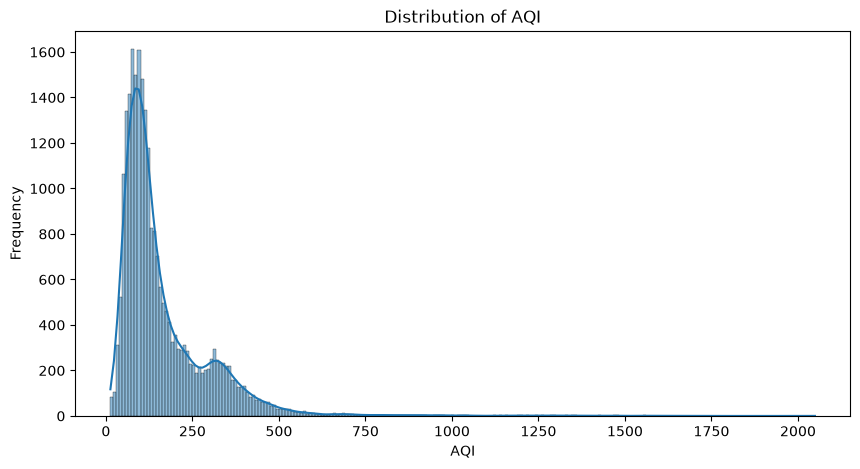

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data['AQI'].dropna(),
    kde=True
)

plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

## 13. AQI Category Distribution

The `AQI_Bucket` column represents the AQI category.

Examples include:

- Good
- Satisfactory
- Moderate
- Poor
- Very Poor
- Severe

We will visualize the number of records in each category.

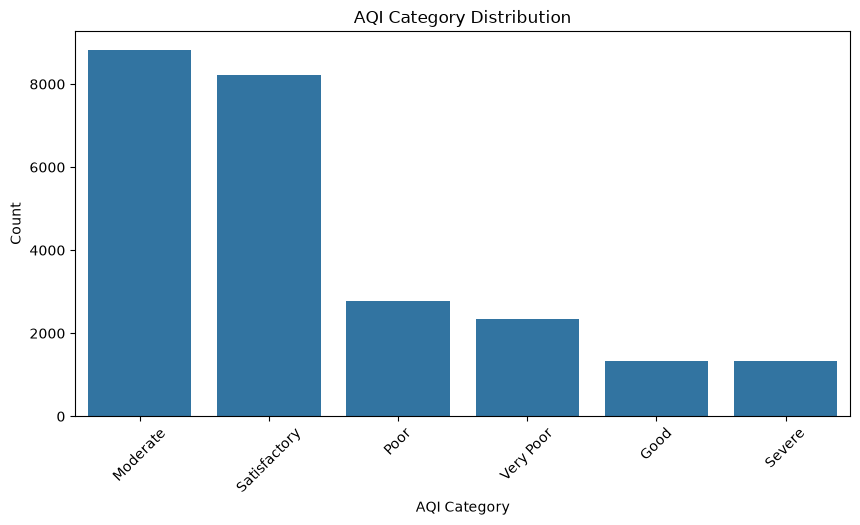

In [16]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=data,
    x='AQI_Bucket',
    order=data['AQI_Bucket'].value_counts().index
)

plt.title("AQI Category Distribution")
plt.xlabel("AQI Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## 14. Number of Records by City

Let's see how many observations are available for each city.

In [17]:
city_counts = data['City'].value_counts()

print(city_counts)

City
Ahmedabad             2009
Bengaluru             2009
Chennai               2009
Delhi                 2009
Lucknow               2009
Mumbai                2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Ernakulam              162
Kochi                  162
Aizawl                 113
Name: count, dtype: int64


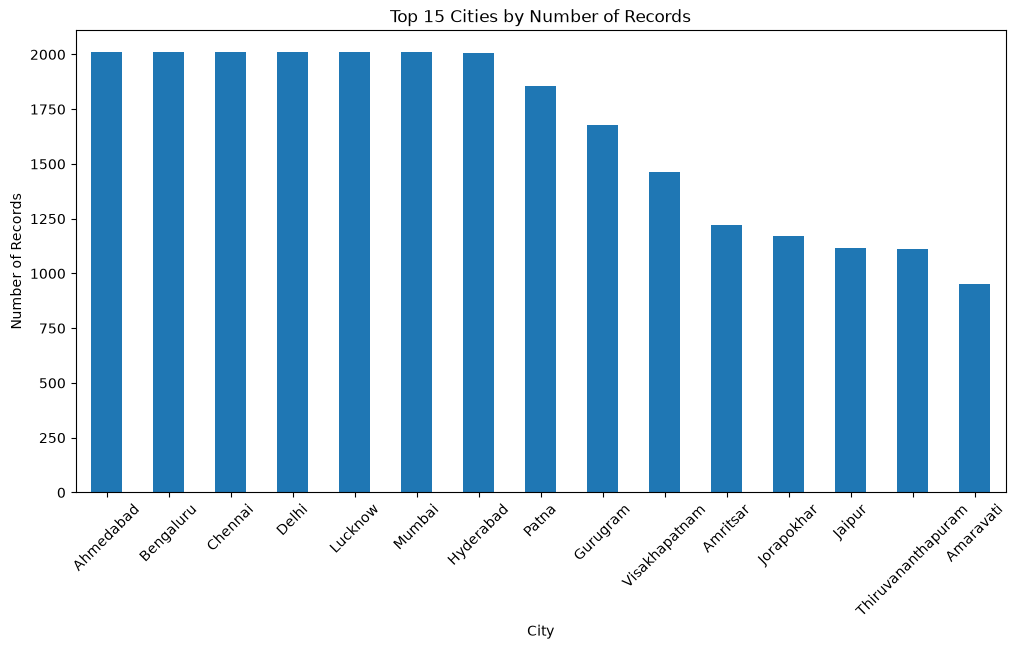

In [18]:
plt.figure(figsize=(12, 6))

city_counts.head(15).plot(kind='bar')

plt.title("Top 15 Cities by Number of Records")
plt.xlabel("City")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.show()

## 15. Air Pollutant Variables

The dataset contains several air pollutants:

- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- Xylene

We will analyze their relationship with AQI.

In [19]:
pollutants = [
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'NH3',
    'CO',
    'SO2',
    'O3',
    'Benzene',
    'Toluene',
    'Xylene'
]

print(pollutants)

['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']


## 16. Correlation Analysis

Correlation measures the relationship between numerical variables.

The correlation value ranges from:

- +1 → Strong positive relationship
- 0 → No linear relationship
- -1 → Strong negative relationship

We will create a correlation heatmap for numerical variables.

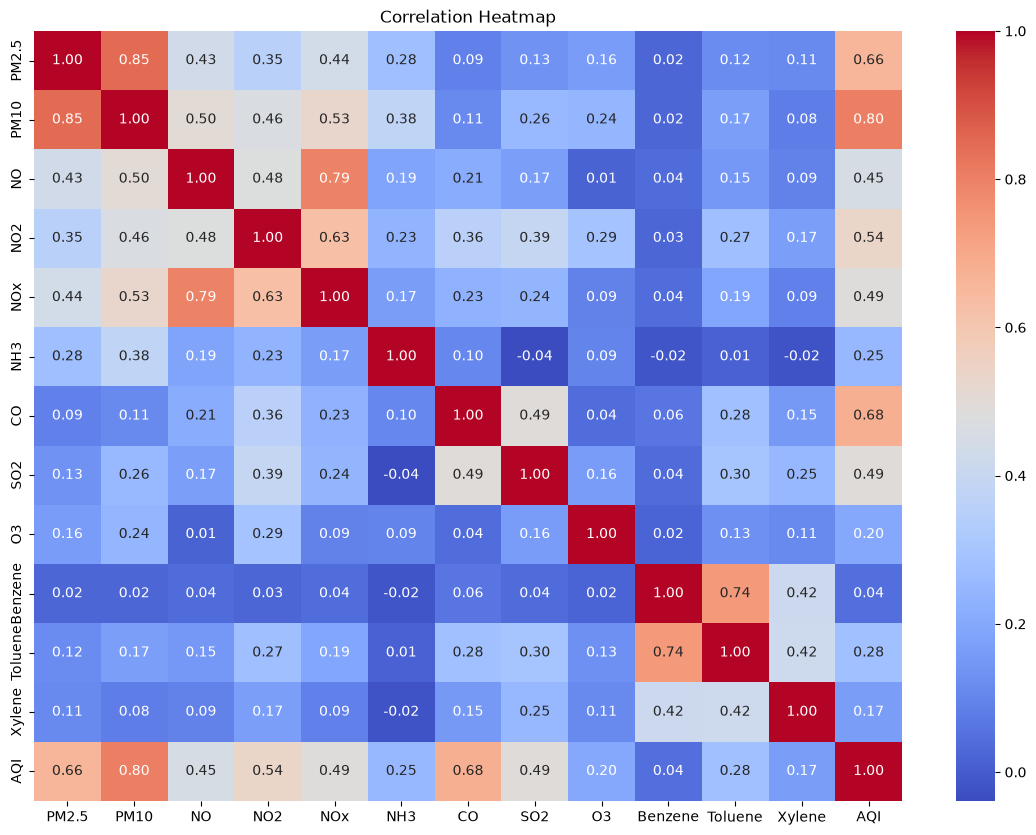

In [20]:
corr = data.select_dtypes(
    include='number'
).corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [21]:
data.select_dtypes(include='number')

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
0,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN
1,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN
2,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN
3,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN
4,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0
29527,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0
29528,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0
29529,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0


## 17. Correlation of Pollutants with AQI

Let's identify which pollutants have the strongest relationship with AQI.

In [22]:
aqi_corr = corr['AQI'].sort_values(
    ascending=False
)

print(aqi_corr)

AQI        1.000000
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Xylene     0.165532
Benzene    0.044407
Name: AQI, dtype: float64


## 18. Pairplot

A pairplot helps us visualize relationships between multiple numerical variables.

Since the dataset is large, we will use a sample of the data to make visualization faster.

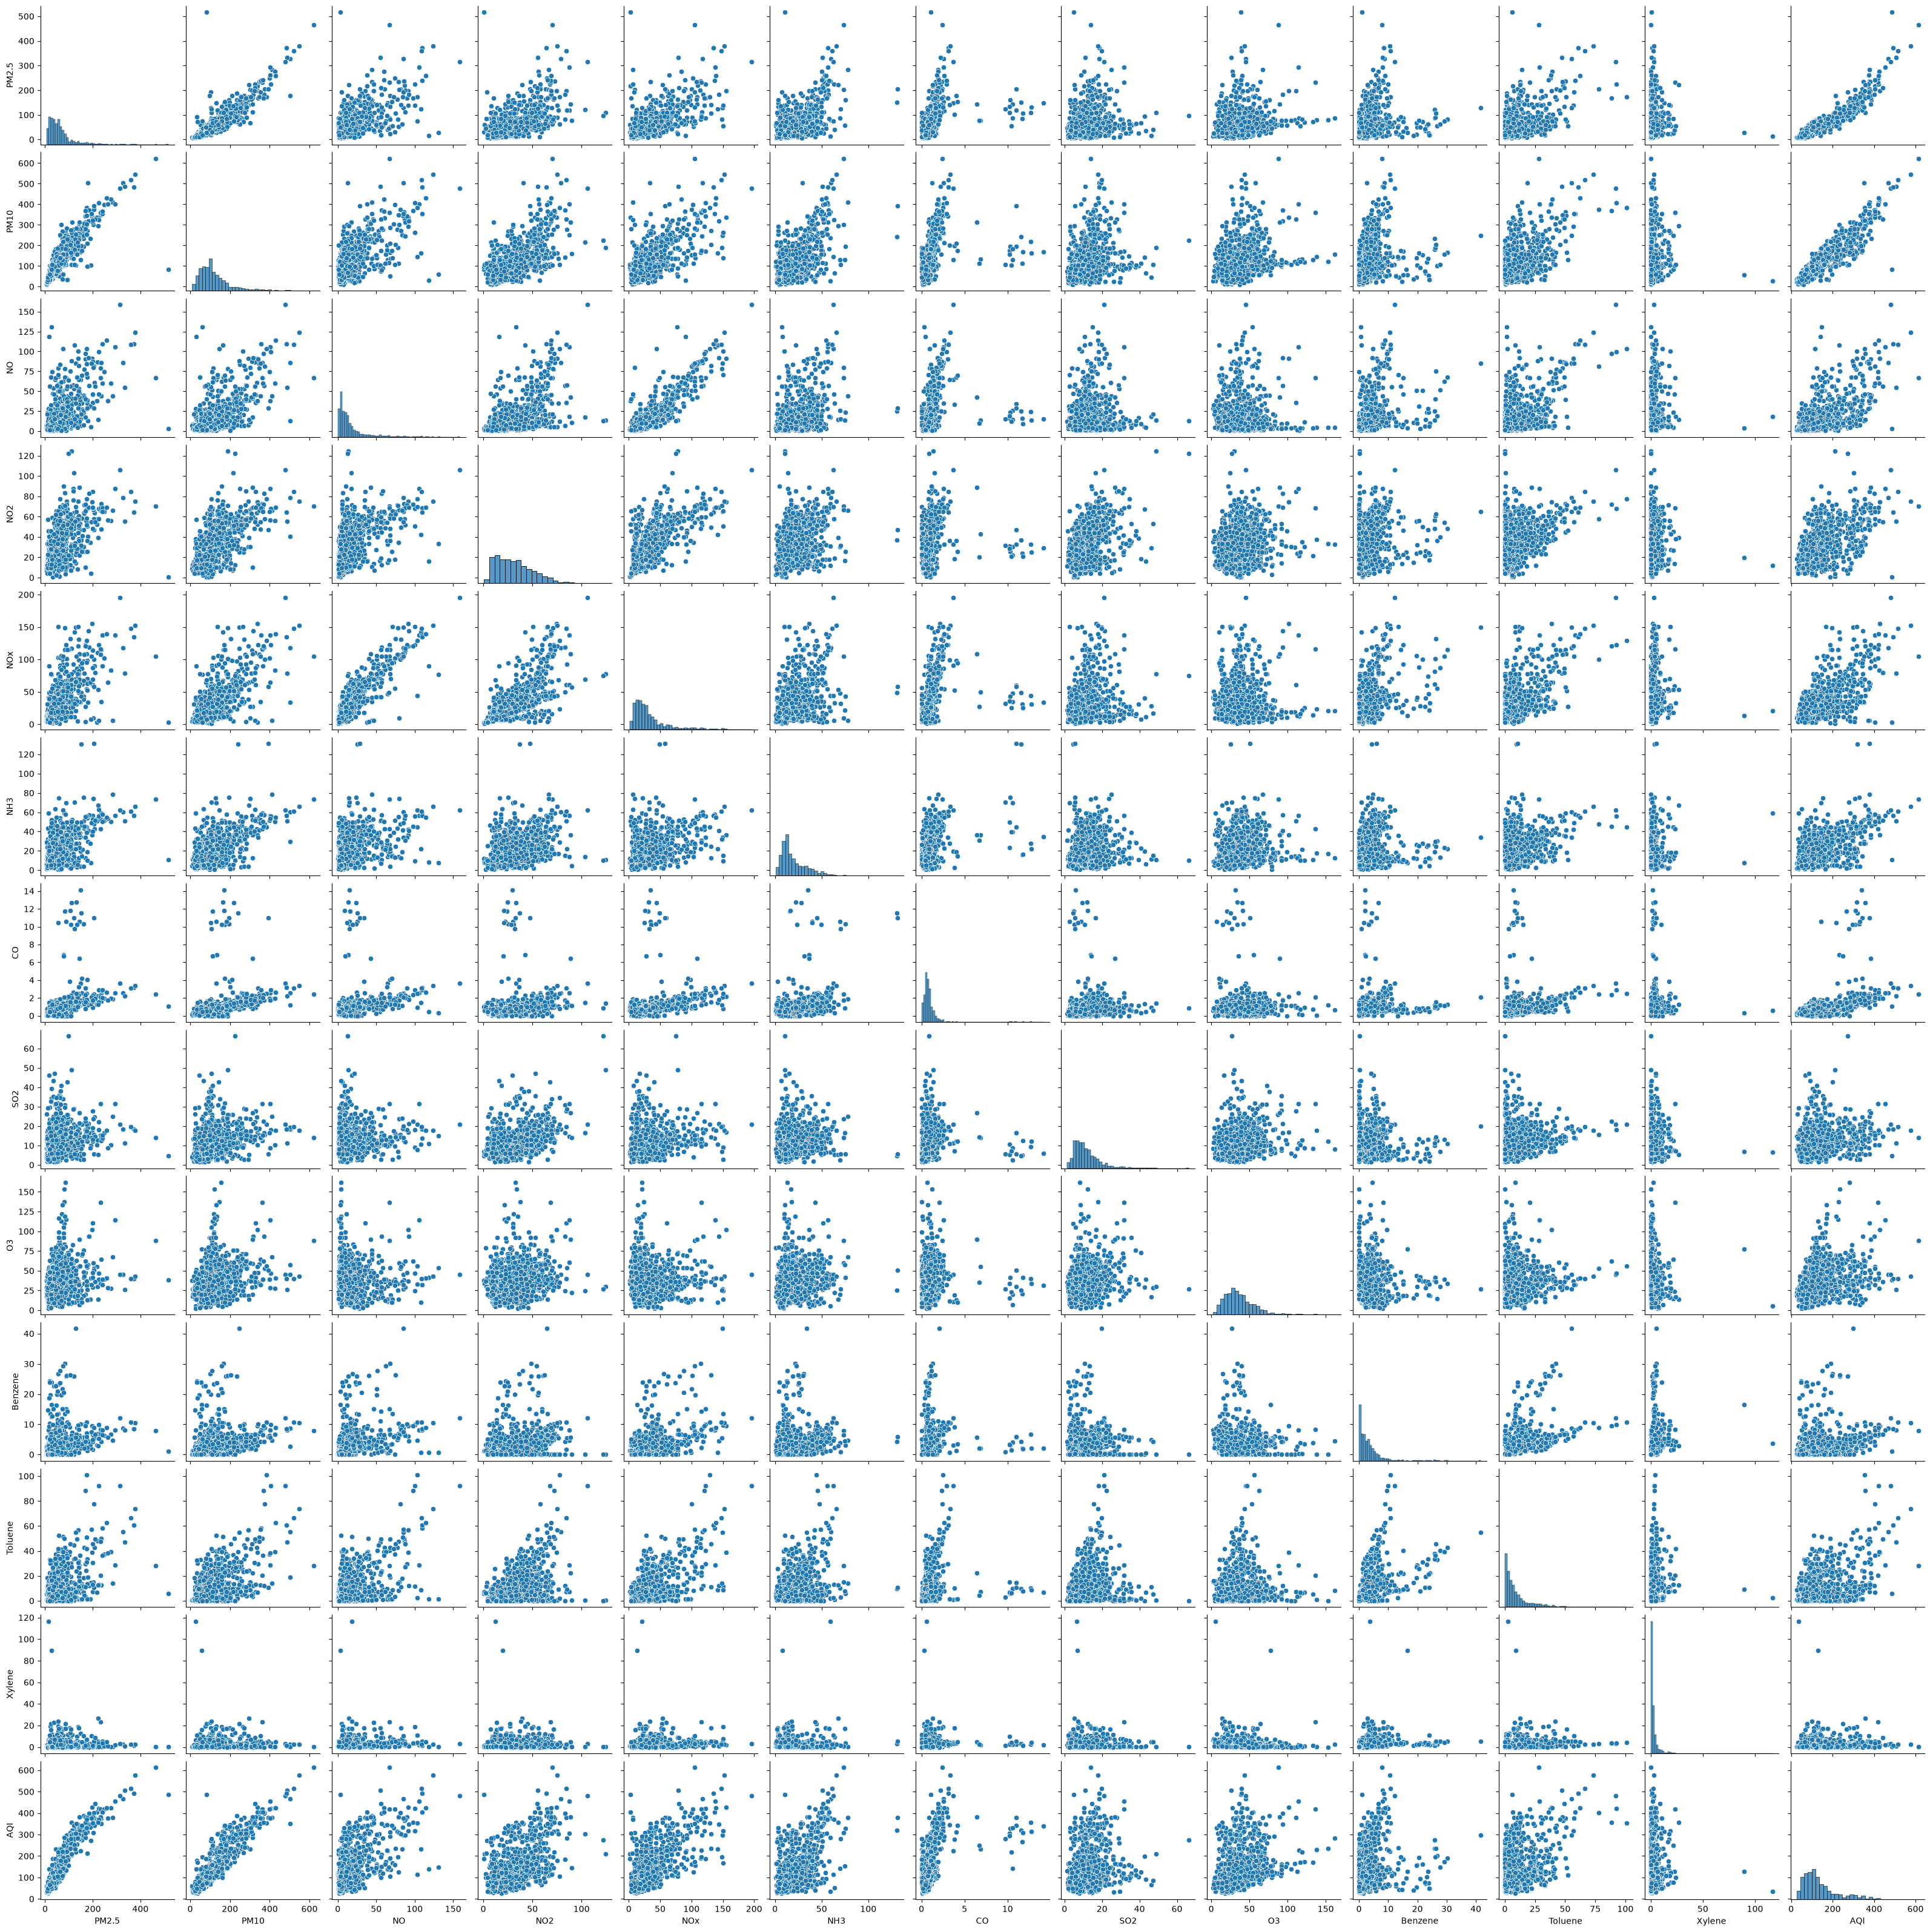

In [23]:
pair_data = data[
    pollutants + ['AQI']
].dropna().sample(
    min(1000, len(data)),
    random_state=42
)

sns.pairplot(pair_data)

plt.show()

# Machine Learning

## 19. Prepare Data for Machine Learning

Our objective is to predict AQI using different air pollutant measurements.

### Features (X)

The input variables will be:

- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- Xylene

### Target (y)

The target variable is:

**AQI**

In [24]:
model_data = data[
    pollutants + ['AQI']
].dropna()

print("Model data shape:", model_data.shape)

Model data shape: (6236, 13)


## 20. Define Features and Target

X contains the independent variables/features.

y contains the dependent variable/target that we want to predict.

In [25]:
X = model_data[pollutants]

y = model_data['AQI']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6236, 12)
y shape: (6236,)


## 21. Train-Test Split

We divide the dataset into two parts:

- 80% → Training data
- 20% → Testing data

The model learns patterns from the training data and is evaluated on unseen testing data.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4988, 12)
Testing data: (1248, 12)


## 22. Feature Scaling

Different pollutants have different numerical ranges.

StandardScaler transforms the features so that they are on a similar scale.

Scaling is particularly useful for Linear Regression and other algorithms that are sensitive to feature scale.

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# 23. Linear Regression

Linear Regression is a supervised Machine Learning algorithm used for predicting continuous numerical values.

In this project, it will be used to predict AQI.

In [28]:
lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[42.9 ,37.81,-0.61,...,-1.01,-2.46,-1.2 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,140.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](12,)","[158.84, 88.33, 74.96,..., 43.01, 22.08, 19.57]"


In [29]:
y_pred_lr = lr_model.predict(
    X_test_scaled
)

print(y_pred_lr[:10])

[ 69.37188961 244.78343816 102.71900607  51.35986339  67.39630466
 140.17729976 251.3543965  132.70450573  63.49754217 197.59597697]


## 24. Model Evaluation

We will use the following metrics:

### MAE
Mean Absolute Error measures the average absolute difference between actual and predicted values.

### RMSE
Root Mean Squared Error measures the average prediction error and gives more importance to large errors.

### R² Score
R² Score measures how well the model explains the variation in the target variable.

Higher R² is generally better, while lower MAE and RMSE are better.

In [30]:
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(model_name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("-" * 40)

    return mae, rmse, r2

In [31]:
lr_mae, lr_rmse, lr_r2 = evaluate_model(
    y_test,
    y_pred_lr,
    "Linear Regression"
)

Linear Regression
MAE: 18.153468625460988
RMSE: 25.52169238708361
R2 Score: 0.9217139055744
----------------------------------------


## 25. Actual vs Predicted AQI

We compare actual AQI values with the AQI values predicted by our model.

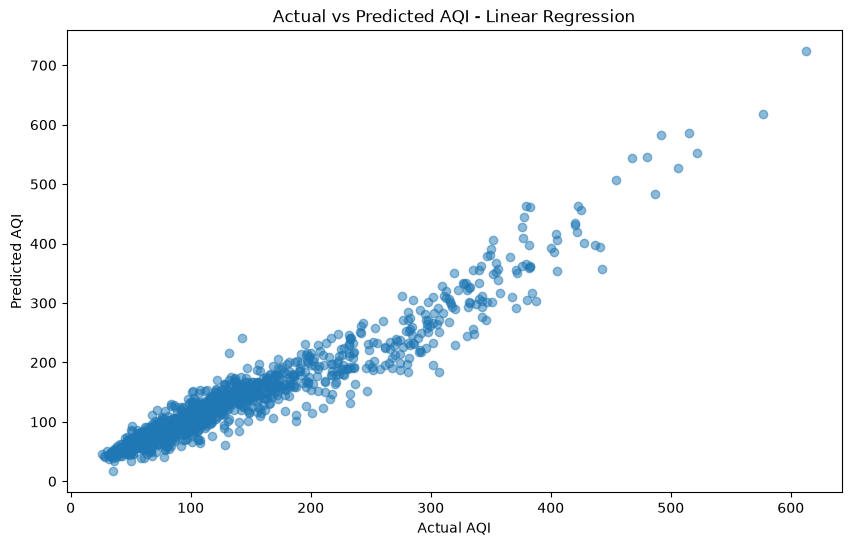

In [32]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.5
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title(
    "Actual vs Predicted AQI - Linear Regression"
)

plt.show()

# 26. Decision Tree Regressor

Decision Tree Regression uses a tree-like structure to make predictions.

It can capture non-linear relationships between pollutant levels and AQI.

In [33]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_model.fit(
    X_train,
    y_train
)

y_pred_dt = dt_model.predict(
    X_test
)

In [34]:
dt_mae, dt_rmse, dt_r2 = evaluate_model(
    y_test,
    y_pred_dt,
    "Decision Tree"
)

Decision Tree
MAE: 16.97915184426148
RMSE: 25.710295166854856
R2 Score: 0.9205525773479565
----------------------------------------


# 27. Random Forest Regressor

Random Forest is an ensemble Machine Learning algorithm.

It combines multiple decision trees to produce a more robust prediction.

Random Forest can handle non-linear relationships and interactions between different pollutant variables.

In [35]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

In [36]:
rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)

Random Forest
MAE: 13.863165064102564
RMSE: 20.584038425455805
R2 Score: 0.9490754903911616
----------------------------------------


# 28. Model Comparison

We compare the performance of all three Machine Learning models:

1. Linear Regression
2. Decision Tree
3. Random Forest

The model with a higher R² score and lower MAE/RMSE generally provides better performance.

In [37]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    
    'MAE': [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    
    'RMSE': [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    
    'R2 Score': [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,18.153469,25.521692,0.921714
1,Decision Tree,16.979152,25.710295,0.920553
2,Random Forest,13.863165,20.584038,0.949075


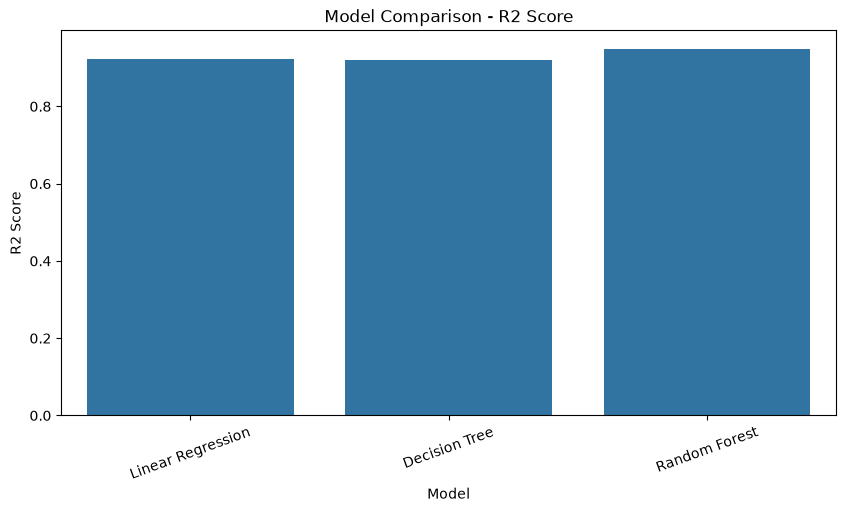

In [38]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title("Model Comparison - R2 Score")

plt.xticks(rotation=20)

plt.show()

# 29. Feature Importance

Random Forest provides feature importance values.

Feature importance tells us which pollutants contribute more to the prediction of AQI according to the trained Random Forest model.

In [39]:
feature_importance = pd.DataFrame({
    'Feature': pollutants,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,PM2.5,0.829263
1,PM10,0.111663
6,CO,0.015550
8,O3,0.009613
5,NH3,0.007105
2,NO,0.005081
4,NOx,0.004841
3,NO2,0.004153
7,SO2,0.003495
10,Toluene,0.003259


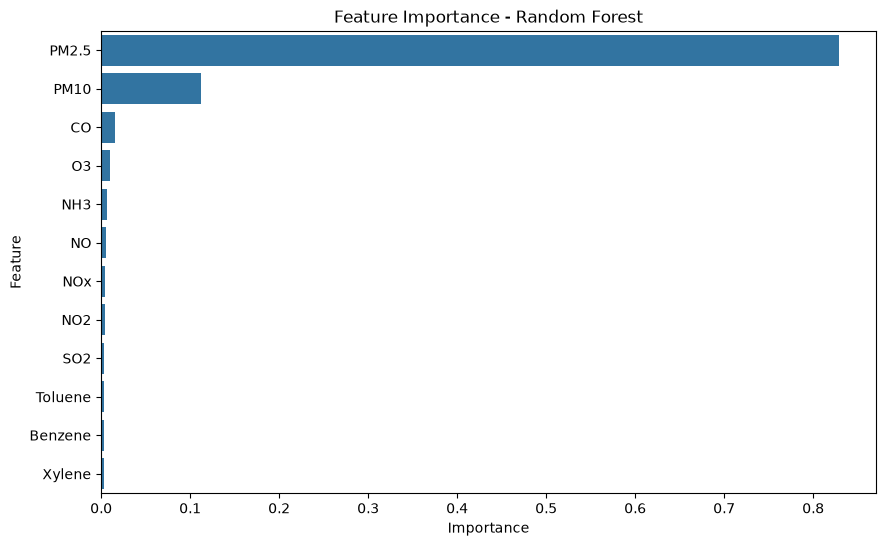

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance - Random Forest")

plt.show()

# 30. Final AQI Prediction

We will use the trained Random Forest model to predict AQI for a new set of pollutant values.

In [41]:
new_data = pd.DataFrame({
    'PM2.5': [50],
    'PM10': [100],
    'NO': [20],
    'NO2': [30],
    'NOx': [40],
    'NH3': [20],
    'CO': [1],
    'SO2': [20],
    'O3': [40],
    'Benzene': [2],
    'Toluene': [5],
    'Xylene': [1]
})

predicted_aqi = rf_model.predict(
    new_data
)

print("Predicted AQI:", predicted_aqi[0])

Predicted AQI: 108.73


# 31. Conclusion

In this project, we analyzed an Air Quality dataset containing pollution measurements from different cities.

The major steps performed were:

- Data loading
- Data exploration
- Missing value analysis
- Data visualization
- Correlation analysis
- Feature selection
- Train-test splitting
- Feature scaling
- Machine Learning model training
- Model evaluation
- Model comparison
- AQI prediction

We trained Linear Regression, Decision Tree and Random Forest regression models.

The models were evaluated using MAE, RMSE and R² Score.

Based on the evaluation results, the model with the best performance can be selected for predicting AQI.

This project demonstrates how Machine Learning can be used to analyze air pollution data and predict Air Quality Index values.

In [42]:
pollutants = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
    'NH3', 'CO', 'SO2', 'O3',
    'Benzene', 'Toluene', 'Xylene'
]

In [43]:
pollutants

['PM2.5',
 'PM10',
 'NO',
 'NO2',
 'NOx',
 'NH3',
 'CO',
 'SO2',
 'O3',
 'Benzene',
 'Toluene',
 'Xylene']

In [44]:
y = data['AQI']

In [45]:
y

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
29526    41.0
29527    70.0
29528    68.0
29529    54.0
29530    50.0
Name: AQI, Length: 29531, dtype: float64